<a href="https://colab.research.google.com/github/will-mccormack/CS-M148-Proj/blob/main/Project_Check_In_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install scikit-lego

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.3/227.3 kB 3.0 MB/s eta 0:00:00


In [12]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# pd.set_option('display.max_columns', None)

In [3]:
cleaned_data = pd.read_csv("https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/train.csv")
validation_data = pd.read_csv("https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/validation.csv")

In [9]:
x_train = cleaned_data.drop(columns=["popularity","track_genre"])
y_train = cleaned_data["popularity"]
x_val = validation_data.drop(columns=["popularity","track_genre"])
y_val = validation_data["popularity"]

In [10]:
# scale the data
pipeline = Pipeline([('scaler',StandardScaler()),('pca', PCA(n_components=0.95))])
pipeline.fit(x_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.95))])

In [13]:
x_train_transformed = pipeline.transform(x_train)
x_val_transformed = pipeline.transform(x_val)

print("Original data shape:",x_train.shape)
print("Transformed data shape:", x_train_transformed.shape)

pca_model = pipeline.named_steps['pca']
explained_variance = pca_model.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)
culmulative_variance = np.cumsum(explained_variance)
print("Culmulative variance:", culmulative_variance)

Original data shape: (61873, 14)
Transformed data shape: (61873, 12)
Explained variance ratio: [0.19744873 0.11494916 0.09800951 0.08777442 0.07401932 0.06936525
 0.06480156 0.06325389 0.0605284  0.05514167 0.04575873 0.03386287]
Culmulative variance: [0.19744873 0.31239788 0.4104074  0.49818181 0.57220114 0.64156639
 0.70636795 0.76962183 0.83015024 0.88529191 0.93105064 0.9649135 ]


These results show that we only need 12 columns to explain ~95% (0.965) of the variance of our dataset since the original was 14 and the transformed was 12.

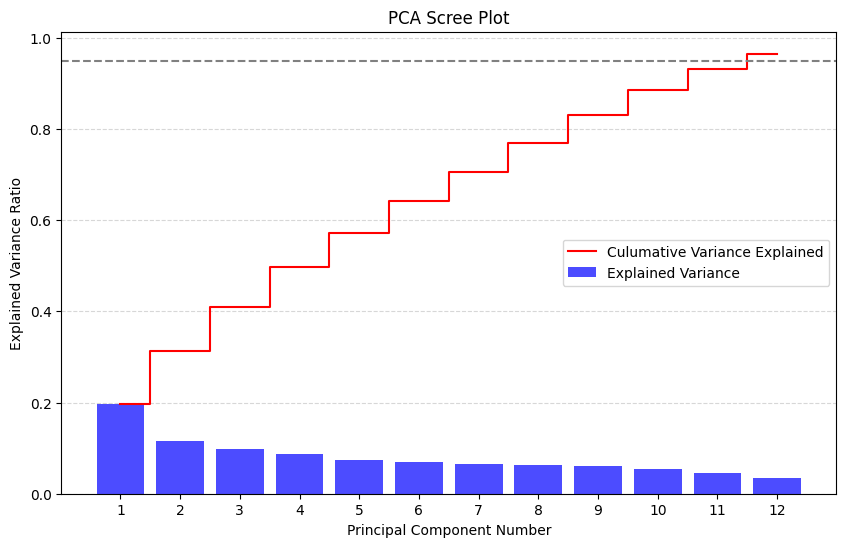

In [14]:
from matplotlib import lines
# visualize with scree plot
plt.figure(figsize=(10,6))
plt.bar(range(1,len(explained_variance)+1),explained_variance,label='Explained Variance',color='blue',alpha=0.7,align='center')
plt.step(range(1,len(culmulative_variance)+1),culmulative_variance,where='mid',label='Culumative Variance Explained',color='red')
plt.title('PCA Scree Plot')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Number')
plt.legend(loc='best')

# line for 0.95 threshold
plt.axhline(y=0.95,color='gray',linestyle='--',label='95% Threshold')

plt.xticks(range(1,len(explained_variance)+1))
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

The scree plot tells us that PC1 explains the most variance (~0.2) and then explained variance descends. This plot explains why PCA chose 12 components to capture 95% of the total variance in our data. We can reduce our data by 2 dimensions. We can see what these new components are made of below:

In [16]:
feature_names = x_train.columns
component_labels = [f"PC{i+1}" for i in range(pca_model.n_components_)]

loadings_df = pd.DataFrame(
    pca_model.components_,
    columns=feature_names,
    index=component_labels
)

print(loadings_df)

      duration_ms  explicit  danceability    energy       key  loudness  \
PC1     -0.036271  0.121924      0.178000  0.527104  0.046598  0.522098   
PC2     -0.401968  0.201826      0.466473 -0.224837  0.003482 -0.067431   
PC3     -0.037724  0.475396     -0.227291  0.027369  0.020749 -0.041115   
PC4     -0.196578 -0.176526     -0.343502  0.017511 -0.422649  0.076259   
PC5     -0.102433 -0.361486     -0.199949 -0.011135  0.626552 -0.004985   
PC6     -0.462884 -0.088439     -0.190866 -0.020415  0.211263  0.021963   
PC7      0.264359 -0.348967      0.079677  0.092247 -0.176523  0.089982   
PC8      0.241951 -0.241856      0.278622 -0.014594 -0.122862 -0.230473   
PC9      0.426092  0.155401      0.057954 -0.026240  0.558233  0.004442   
PC10    -0.501299 -0.140077      0.099447  0.198395  0.151148 -0.020855   
PC11     0.017215 -0.549459     -0.050137  0.032291 -0.003114  0.091991   
PC12    -0.090455 -0.147287      0.609065 -0.216621  0.027367  0.062078   

          mode  speechin

We can use our transformed data to train a machine learning model and we can use this tabel to understand what the model is learning from.